In [2]:
import sys
print(sys.executable)

C:\Users\Admin\AppData\Local\Programs\Python\Python313\python.exe


In [5]:
import sys
!{sys.executable} -m pip install scikit-learn



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r'C:\Users\Admin\OneDrive\Desktop\BI project\Data Folder\bank_cleaned.csv')
print("Data loaded!")
print("shape:", df.shape)

Data loaded!
shape: (42770, 18)


In [6]:
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'y_encoded'],
      dtype='str')


In [7]:
print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  \
0  unknown    5   may       261         1     -1         0  unknown  no   
1  unknown    5   may       151         1     -1         0  unknown  no   
2  unknown    5   may        76         1     -1         0  unknown  no   
3  unknown    5   may        92         1     -1         0  unknown  no   
4  unknown    5   may       198         1     -1         0  unknown  no   

   y_encoded  
0          0  
1          0  
2          0  
3          0  
4          0  


In [10]:
feature =['age','balance','duration','campaign','pdays','previous']
x = df[feature]
y= df['y_encoded']

print("Feature shape:",x.shape)
print("target shape:",y.shape)
print("\nsample of x:")
print(x.head())

Feature shape: (42770, 6)
target shape: (42770,)

sample of x:
   age  balance  duration  campaign  pdays  previous
0   58     2143       261         1     -1         0
1   44       29       151         1     -1         0
2   33        2        76         1     -1         0
3   47     1506        92         1     -1         0
4   33        1       198         1     -1         0


In [12]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

print("Training set:",x_train.shape)
print("Testing set: ",x_test.shape)
print("Train target:",y_train.shape)
print("Test target:",y_test.shape)

Training set: (34216, 6)
Testing set:  (8554, 6)
Train target: (34216,)
Test target: (8554,)


In [13]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

print(" Model trained successfully!")
print("Classes :",model.classes_)

 Model trained successfully!
Classes : [0 1]


In [15]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy :",round(accuracy*100,2),"%")
print("\nDetailed Report:")
print(classification_report(y_test,y_pred))

Model Accuracy : 88.95 %

Detailed Report:
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7552
           1       0.60      0.17      0.27      1002

    accuracy                           0.89      8554
   macro avg       0.75      0.58      0.60      8554
weighted avg       0.86      0.89      0.86      8554



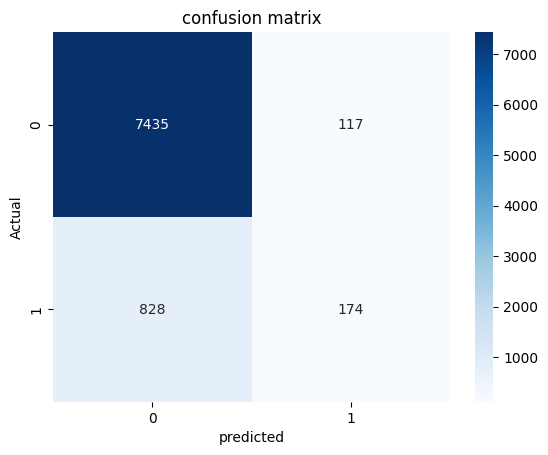

In [16]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('confusion matrix')
plt.xlabel('predicted')
plt.ylabel('Actual')
plt.show()



In [17]:
new_customer = pd.DataFrame({
    'age': [35],
    'balance': [2000],
    'duration': [300],
    'campaign': [2],
    'pdays': [-1],
    'previous': [0]
})

prediction = model.predict(new_customer)
probability = model.predict_proba(new_customer)

print("Customer Profile:")
print("Age: 35 | Balance: ₹2000 | Call Duration: 300 sec")
print()
if prediction[0] == 1:
    print("✅ Prediction: WILL SUBSCRIBE")
else:
    print("❌ Prediction: WILL NOT SUBSCRIBE")
    
print(f"Probability of subscribing: {round(probability[0][1]*100, 2)}%")
print(f"Probability of NOT subscribing: {round(probability[0][0]*100, 2)}%")

Customer Profile:
Age: 35 | Balance: ₹2000 | Call Duration: 300 sec

❌ Prediction: WILL NOT SUBSCRIBE
Probability of subscribing: 10.37%
Probability of NOT subscribing: 89.63%
